# 우송대학교 컴퓨터정보보안전공 202110716 백지원

## **단순선형회귀분석 예제**

### 데이터 준비

- 수축기 혈압(SBP, 독립변수)에 따른 이완기 혈압(DBP, 종속변수)의 회귀분석
- 데이터를 가상으로 생성하여 회귀분석을 수행


In [12]:
# 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 데이터프레임 출력 옵션 및 그래프 크기 설정
pd.options.display.float_format = '{:.2f}'.format
plt.rcParams['figure.figsize'] = (8, 5)

# 데이터 생성
np.random.seed(42)

# 30명의 환자에 대한 수축기 혈압(SBP) 데이터 생성
# 평균 120, 표준편차 15
df = pd.DataFrame({
    'SBP' : np.random.normal(120, 15, 30)
})

# 이완기 혈압(DBP) = 0.7 * 수축기 혈압(SBP) + 랜덤 노이즈
df['DBP'] = -5.0 + 0.7 * df['SBP'] + np.random.randint(-15, 15, 30)

# 데이터 확인
df.head()

,SBP,DBP
0,127.45,88.22
1,117.93,89.55
2,129.72,84.80
3,142.85,106.99
4,116.49,67.54


### 변수의 데이터 유형 확인

- 변수의 데이터 유형을 확인하여 수치형 변수인지 확인

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SBP     30 non-null     float64
 1   DBP     30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [14]:
# 기술통계량 확인
df.describe()

,SBP,DBP
count,30.00,30.00
mean,117.18,76.12
std,13.50,14.22
min,91.30,52.89
25%,111.13,66.91
50%,116.49,72.81
75%,125.41,87.59
max,143.69,108.58


### 산점도 분석

- 산점도 분석 결과 수축기 혈압과 이완기 혈압 사이에 양의 선형관계가 있음.

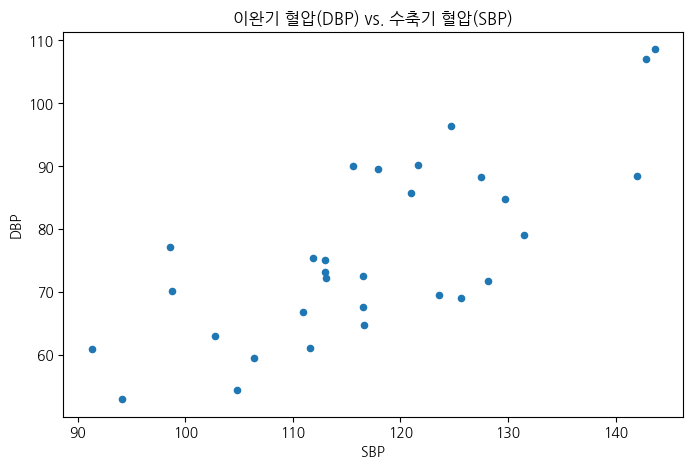

In [15]:
# 산점도 그래프
df.plot(
    kind='scatter',
    x='SBP',
    y='DBP',
    title='이완기 혈압(DBP) vs. 수축기 혈압(SBP)'
);


### 상관분석

- 상관계수는 0.75로 강한 양의 상관관계로 나타남

In [16]:
# 독립변수와 종속변수의 상관계수
from scipy.stats import pearsonr

pearson_corr, pearson_p = pearsonr(df['DBP'], df['SBP'])
print(f"Pearson 상관계수: {pearson_corr:.3f}, p-값: {pearson_p:.3f}")

if pearson_p < 0.05:
    print("Pearson 상관계수는 통계적으로 유의함.")
else:
    print("Pearson 상관계수는 통계적으로 유의하지 않음.")


Pearson 상관계수: 0.751, p-값: 0.000
Pearson 상관계수는 통계적으로 유의함.


### 회귀계수의 추정

In [17]:
import statsmodels.formula.api as smf

# 회귀모형 생성
formula = 'DBP ~ SBP'

# OLS 클래스로 선형회귀모형의 객체를 생성
model = smf.ols(formula, data=df)

# fit 메서드로 모형 추정. 추정 결과는 결과 객체에 저장
result = model.fit()


In [18]:
# 추정한 회귀선
print('='*20, '1. 표본회귀선(모회귀선의 추정)', '='*20)
print(f"절편은 {result.params['Intercept']}이고, 기울기는 {result.params['SBP']}")
print(f"따라서, 추정된 회귀선은 ")
print(f"DBP = {result.params['Intercept']:.2f} + {result.params['SBP']:.2f}*SBP")

# 회귀모형의 적합도 평가
print('='*20, '2. 회귀모형의 적합도 평가', '='*20)
print('결정계수: ', result.rsquared)

# 회귀계수 유의성 검정 (일반적으로 절편은 하지 않음)
print('='*20, '3. 회귀계수의 유의성 검정', '='*20)
print(f"SBP 회귀계수의 p-값: {result.pvalues['SBP']:.3f}")
if result.pvalues['SBP'] < 0.05:
    print('회귀계수는 통계적으로 유의함.')
else:
    print('회귀계수는 통계적으로 유의하지 않음.')

# 회귀모형의 유의성 검정
print('='*20, '4. 회귀모형의 유의성 검정', '='*20)
print(f"F-통계량: {result.fvalue:.2f}, p-값: {result.f_pvalue:.3f}")
if result.f_pvalue < 0.05:
    print('회귀모형은 통계적으로 유의함.')
else:
    print('회귀모형은 통계적으로 유의하지 않음.')


==================== 1. 표본회귀선(모회귀선의 추정) ====================
절편은 -16.499809964665676이고, 기울기는 0.7904592019618324
따라서, 추정된 회귀선은 
DBP = -16.50 + 0.79*SBP
==================== 2. 회귀모형의 적합도 평가 ====================
결정계수:  0.5633721028347716
==================== 3. 회귀계수의 유의성 검정 ====================
SBP 회귀계수의 p-값: 0.000
회귀계수는 통계적으로 유의함.
==================== 4. 회귀모형의 유의성 검정 ====================
F-통계량: 36.13, p-값: 0.000
회귀모형은 통계적으로 유의함.


In [19]:
# summary 메서드로 회귀분석 결과 출력
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                    DBP   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.548
Method:                 Least Squares   F-statistic:                     36.13
Date:                Tue, 08 Jul 2025   Prob (F-statistic):           1.78e-06
Time:                        23:25:22   Log-Likelihood:                -109.26
No. Observations:                  30   AIC:                             222.5
Df Residuals:                      28   BIC:                             225.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -16.4998     15.509     -1.064      0.2

## 응용 코드

### 1. SBP(수축기 혈압) vs DBP(이완기 혈압) 의 상관계수 분석 (Pearson)

- 수축기 혈압(SBP)과 이완기 혈압(DBP) 사이에 선형적 상관관계가 존재하는지 확인
- 상관계수와 p-값을 통해 통계적 유의성 평가

Pearson 상관계수: 0.751, p-값: 0.000
해석: 두 변수는 통계적으로 유의한 양의 상관관계를 가집니다.


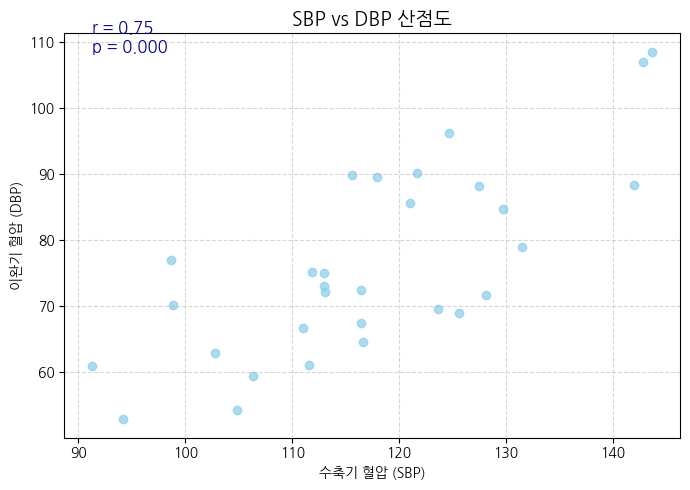

In [20]:
# 상관계수 계산
pearson_corr, pearson_p = pearsonr(df['DBP'], df['SBP'])

# 상관계수 출력
print(f"Pearson 상관계수: {pearson_corr:.3f}, p-값: {pearson_p:.3f}")
if pearson_p < 0.05:
    interpretation = "두 변수는 통계적으로 유의한 양의 상관관계를 가집니다." if pearson_corr > 0 else "두 변수는 통계적으로 유의한 음의 상관관계를 가집니다."
else:
    interpretation = "두 변수 간의 상관관계는 통계적으로 유의하지 않습니다."
print("해석:", interpretation)

# 시각화
plt.figure(figsize=(7, 5))
plt.scatter(df['SBP'], df['DBP'], color='skyblue', alpha=0.7)
plt.title('SBP vs DBP 산점도', fontsize=14)
plt.xlabel('수축기 혈압 (SBP)')
plt.ylabel('이완기 혈압 (DBP)')

# 텍스트로 상관계수 출력
text = f"r = {pearson_corr:.2f}\np = {pearson_p:.3f}"
plt.text(min(df['SBP']), max(df['DBP']), text, fontsize=12, color='darkblue')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 2. 회귀모형 응용 코드

- SBP(수축기 혈압)으로 DBP(이완기 혈압)를 예측하는 직선 모형 제작
- 회귀직선을 그래프에 같이 표시

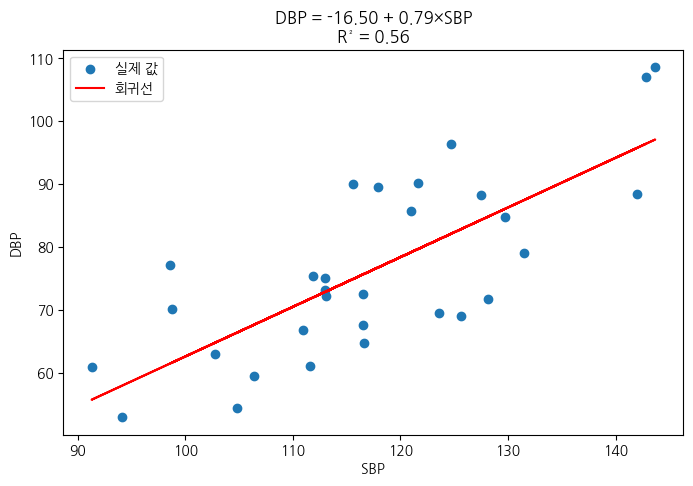

In [21]:
# 회귀모형 생성 및 적합
result = smf.ols('DBP ~ SBP', data=df).fit()

# 회귀선 시각화
plt.scatter(df['SBP'], df['DBP'], label='실제 값')
plt.plot(df['SBP'], result.fittedvalues, color='red', label='회귀선')
plt.title('DBP = {:.2f} + {:.2f}×SBP\nR² = {:.2f}'.format(
    result.params['Intercept'], result.params['SBP'], result.rsquared))
plt.xlabel('SBP')
plt.ylabel('DBP')
plt.legend()
plt.show()
